# Carga de datos

Esta sección carga el dataset de Pokémon y muestra una vista inicial de las columnas y registros.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "data/pokemon_complete_2025.csv"

# Cargar los datos con pandas para trabajar de forma consistente y evitar flujos duplicados.
df = pd.read_csv(DATA_PATH, on_bad_lines="skip")

print("Columnas disponibles:", df.columns.tolist())
print(df.head(3))

Columnas disponibles: ['pokedex_id', 'name', 'genus', 'generation', 'type_1', 'type_2', 'num_types', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'base_stat_total', 'height_m', 'weight_kg', 'base_experience', 'ability_1', 'ability_2', 'hidden_ability', 'color', 'shape', 'habitat', 'growth_rate', 'egg_groups', 'is_legendary', 'is_mythical', 'is_baby', 'capture_rate', 'base_happiness', 'hatch_counter', 'gender_rate', 'description', 'sprite_url', 'is_dual_type', 'bmi', 'attack_defense_ratio', 'physical_total', 'special_total', 'offensive_total', 'defensive_total', 'gender_distribution', 'stat_tier']
   pokedex_id       name         genus generation type_1  type_2  num_types  \
0           1  bulbasaur  Seed Pokémon          I  grass  poison          2   
1           2    ivysaur  Seed Pokémon          I  grass  poison          2   
2           3   venusaur  Seed Pokémon          I  grass  poison          2   

   hp  attack  defense  ...  \
0  45      49       49  ...   

# Limpieza y Preprocesamiento

Convertimos la columna de generaciones en valores numéricos y centralizamos la lógica de conversión.

In [ ]:
import numpy as np
import pandas as pd

# --- DETECCIÓN AUTOMÁTICA DE COLUMNAS ---
# Limpiamos los nombres de las columnas por si tienen espacios locos
df.columns = df.columns.str.strip().str.lower()

# Buscamos la columna que represente el segundo tipo
posibles_nombres_tipo2 = ["type2", "type 2", "type_2", "tipo2", "tipo 2"]
col_tipo2 = next((c for c in df.columns if c in posibles_nombres_tipo2), None)

# 1. Mapa de conversión de generaciones
generation_map = {
    "I": 1, "II": 2, "III": 3, "IV": 4,
    "V": 5, "VI": 6, "VII": 7, "VIII": 8, "IX": 9
}

if "generation" in df.columns:
    df["generation_number"] = (
        df["generation"].astype(str).str.strip().map(generation_map)
        .fillna(0)
        .astype(int)
    )

# 2. Identificar columnas de stats
posibles_stats = {
    "hp", "attack", "defense", "special-attack", "special-defense", 
    "special_attack", "special_defense", "speed", "sp_attack", "sp_defense", "sp_atk", "sp_def"
}
stat_columns = [col for col in df.columns if col in posibles_stats]

def ensure_total_stats(dataframe):
    for col in stat_columns:
        dataframe[col] = pd.to_numeric(dataframe[col], errors='coerce').fillna(0)
    dataframe["total_stats"] = dataframe[stat_columns].sum(axis=1)
    return dataframe

df = ensure_total_stats(df)

# 3. Crear columna para tipo dual (USANDO LA COLUMNA DETECTADA)
if col_tipo2:
    df["es_dual"] = df[col_tipo2].notna() & (df[col_tipo2].astype(str).str.lower() != "nan")
else:
    print("ADVERTENCIA: No se encontró la columna de Tipo 2. Asumiendo todos falsos.")
    df["es_dual"] = False

# Verificamos qué nombres quedaron
print("Nombres de columnas actuales:", df.columns.tolist())
print(df[["generation_number", "total_stats", "es_dual"]].head(8))

KeyError: 'type2'

# Análisis Estadístico

Calculamos la distribución de Pokémon por generación en el dataset y validamos la coherencia de total_stats.

In [ ]:
# Estadísticas de frecuencia de generación.
generation_counts = (
    df["generation_number"]
    .value_counts(sort=False)
    .sort_index()
)

values = generation_counts.index.to_numpy()
counts = generation_counts.to_numpy()

# Estadísticas de distribución de total_stats.
total_stats_mean = df["total_stats"].mean()
total_stats_std = df["total_stats"].std()

print("Generaciones:", values)
print("Conteos:", counts)
print(f"Total stats - media: {total_stats_mean:.2f}, desviación estándar: {total_stats_std:.2f}")

# Cálculo de proporciones Único vs Dual.
type_proportions = df["es_dual"].value_counts(normalize=True) * 100
percent_unique = type_proportions.get(False, 0.0)
percent_dual = type_proportions.get(True, 0.0)
print(f"Único: {percent_unique:.1f}%")
print(f"Dual: {percent_dual:.1f}%")
print(f"Suma porcentajes: {(percent_unique + percent_dual):.1f}%")

Generaciones: [1 2 3 4 5 6 7 8 9]
Conteos: [151 100 135 107 156  72  88  96 120]
Total stats - media: 287.40, desviación estándar: 78.75


# Visualización

Generamos el plot de cantidad de Pokémon por generación y el histograma de poder total.

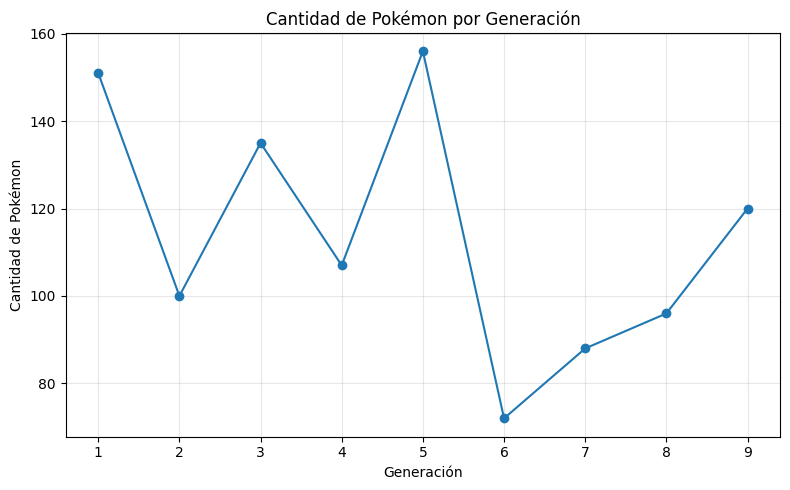

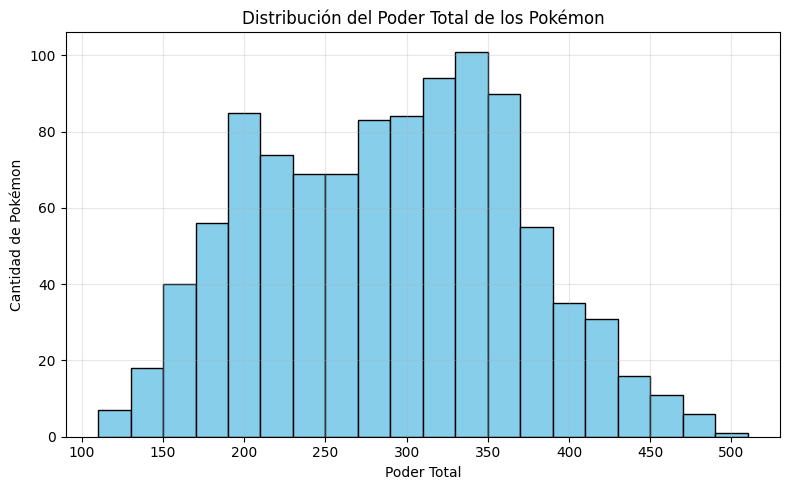

In [ ]:
# =================================================================
# SECCIÓN: VISUALIZACIÓN (CÓDIGO FINAL)
# =================================================================
import matplotlib.pyplot as plt

def generar_graficos_tp(dataframe, x_gen, y_gen):
    # 1. Gráfico de Líneas (Generaciones)
    plt.figure(figsize=(8, 5))
    plt.plot(x_gen, y_gen, marker="o", linestyle="-", color="tab:blue")
    plt.xlabel("Generación")
    plt.ylabel("Cantidad de Pokémon")
    plt.title("Cantidad de Pokémon por Generación")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("grafico_generaciones.png")
    plt.show()

    # 2. Histograma (Poder Total)
    plt.figure(figsize=(8, 5))
    plt.hist(dataframe["total_stats"].dropna(), bins=20, color="skyblue", edgecolor="black")
    plt.xlabel("Poder Total")
    plt.ylabel("Cantidad de Pokémon")
    plt.title("Distribución del Poder Total")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("histograma_poder.png")
    plt.show()

    # 3. Gráfico de Torta (Tipo Único vs Dual)
    # Verificamos si existe la columna, si no, la creamos al vuelo
    if "es_dual" not in dataframe.columns:
        dataframe["es_dual"] = dataframe["type2"].notna()
    
    proportions = dataframe["es_dual"].value_counts(normalize=True)
    
    plt.figure(figsize=(6, 6))
    plt.pie(proportions, labels=["Único", "Dual"], autopct="%1.1f%%", 
            startangle=90, colors=["#66c2a5", "#fc8d62"])
    plt.title("Proporción de Pokémon Tipo Único vs Dual")
    plt.axis("equal")
    plt.tight_layout()
    plt.savefig("pie_tipos.png")
    plt.show()

# EJECUCIÓN ÚNICA
# Asegurate de pasar 'df' (tu dataframe) y los valores de generación
generar_graficos_tp(df, values, counts)